# 16 — Final Model Comparison

Notebook finale di confronto tra:

1. **Siamese downsampled**: FCGR k=6, CNN V3, 25.332 campioni train, Dynamic Semi-Hard, Top-20 reference bank.
2. **Siamese full-train balanced**: FCGR k=6, CNN V3, 96.167 campioni train, balanced batch sampling, Dynamic Semi-Hard, Top-20 reference bank.
3. **Direct CNN multiclass**: FCGR k=6, stessa CNN V3, 96.167 campioni train, balanced batch sampling, Linear(128→12), CrossEntropy.

Questo notebook non fa training. Serve solo per:

- confrontare i numeri finali;
- confrontare Top-1 / Top-3 / Top-5;
- analizzare le confusioni principali;
- produrre tabelle e figure per il report.

Nota importante: se nel confronto viene citata anche la Siamese downsampled del notebook 07b/13, allora idealmente va esportata anche la sua confusion matrix completa. Se non è disponibile come file, il notebook lo segnala nella sezione di preflight.


In [1]:
# ============================================================
# CELL 1 — IMPORTS + PATHS
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
COMPARISON_DIR = ARTIFACTS_DIR / "final_model_comparison"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

SIAMESE_FULL_DIR = ARTIFACTS_DIR / "siamese_fulltrain_balanced"
CNN_DIR = ARTIFACTS_DIR / "cnn_multiclass_fulltrain"

# Eventuale cartella della Siamese downsampled/finale precedente.
# Se hai salvato lì predizioni o confusion matrix, il notebook le caricherà.
SIAMESE_DOWNSAMPLED_DIR = ARTIFACTS_DIR / "siamese_dynamic_semihard_tumor_healthy"

class_names = {
    0: "gastric cancer",
    1: "healthy",
    2: "ovarian cancer",
    3: "prostate cancer",
    4: "colorectal cancer",
    5: "lymphoma",
    6: "cervical adenocarcinoma",
    7: "leukemia",
    8: "hypopharyngeal SCC",
    9: "glioblastoma cancer",
    10: "melanoma",
    11: "hypopharynx cancer"
}

print("Project root:", PROJECT_ROOT)
print("Comparison artifacts:", COMPARISON_DIR)
print("Siamese full-train dir:", SIAMESE_FULL_DIR)
print("Direct CNN dir:", CNN_DIR)
print("Siamese downsampled dir:", SIAMESE_DOWNSAMPLED_DIR)


Project root: D:\Daria\Desktop\eccdna_fcgr_siamese
Comparison artifacts: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\final_model_comparison
Siamese full-train dir: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_fulltrain_balanced
Direct CNN dir: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\cnn_multiclass_fulltrain
Siamese downsampled dir: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_dynamic_semihard_tumor_healthy


In [11]:
# ============================================================
# CELL 2 — FINAL TEST METRICS TABLE
# ============================================================

# Numeri finali consolidati dai notebook 13, 14 e 15.
# Pairwise ROC-AUC ha senso solo per le Siamese.

metrics_df = pd.DataFrame([
    {
        "model": "Siamese downsampled",
        "train_samples": 25332,
        "balancing": "downsampling",
        "objective": "contrastive + semi-hard",
        "pairwise_auc_val": 0.664895,
        "test_top1": 0.3158,
        "test_macro_f1": 0.2784,
        "test_balanced_accuracy": 0.3197,
        "test_top3": 0.6583,
        "test_top5": 0.8253,
        "test_balanced_top3": 0.6561,
        "test_balanced_top5": 0.8209,
    },
    {
        "model": "Siamese full-train balanced",
        "train_samples": 96167,
        "balancing": "balanced batch sampling",
        "objective": "contrastive + semi-hard",
        "pairwise_auc_val": 0.670110,
        "test_top1": 0.306847,
        "test_macro_f1": 0.268841,
        "test_balanced_accuracy": 0.310454,
        "test_top3": 0.664799,
        "test_top5": 0.833352,
        "test_balanced_top3": 0.658991,
        "test_balanced_top5": 0.825019,
    },
    {
        "model": "Direct CNN full-train balanced",
        "train_samples": 96167,
        "balancing": "balanced batch sampling",
        "objective": "cross-entropy softmax classifier",
        "pairwise_auc_val": np.nan,
        "test_top1": 0.328253,
        "test_macro_f1": 0.285780,
        "test_balanced_accuracy": 0.330599,
        "test_top3": 0.675894,
        "test_top5": 0.840861,
        "test_balanced_top3": 0.669850,
        "test_balanced_top5": 0.825723,
    }
])

metrics_df.to_csv(
    COMPARISON_DIR / "final_model_metrics_comparison.csv",
    index=False
)

print("FINAL TEST METRICS")
display(metrics_df)


FINAL TEST METRICS


,model,train_samples,balancing,objective,pairwise_auc_val,test_top1,test_macro_f1,test_balanced_accuracy,test_top3,test_top5,test_balanced_top3,test_balanced_top5
0,Siamese downsampled,25332,downsampling,contrastive + semi-hard,0.664895,0.315800,0.278400,0.319700,0.658300,0.825300,0.656100,0.820900
1,Siamese full-train balanced,96167,balanced batch sampling,contrastive + semi-hard,0.670110,0.306847,0.268841,0.310454,0.664799,0.833352,0.658991,0.825019
2,Direct CNN full-train balanced,96167,balanced batch sampling,cross-entropy softmax classifier,NaN,0.328253,0.285780,0.330599,0.675894,0.840861,0.669850,0.825723


In [12]:
# ============================================================
# CELL 3 — COMPACT REPORT TABLE
# ============================================================

compact_metrics = metrics_df[[
    "model",
    "train_samples",
    "test_top1",
    "test_macro_f1",
    "test_balanced_accuracy",
    "test_top3",
    "test_top5",
    "test_balanced_top3",
    "test_balanced_top5"
]].copy()

for column in compact_metrics.columns:
    if column not in {"model", "train_samples"}:
        compact_metrics[column] = 100 * compact_metrics[column]

print("REPORT TABLE (%)")
display(compact_metrics)

compact_metrics.to_csv(
    COMPARISON_DIR / "final_model_metrics_report_percent.csv",
    index=False
)


REPORT TABLE (%)


,model,train_samples,test_top1,test_macro_f1,test_balanced_accuracy,test_top3,test_top5,test_balanced_top3,test_balanced_top5
0,Siamese downsampled,25332,31.5800,27.8400,31.9700,65.8300,82.5300,65.6100,82.0900
1,Siamese full-train balanced,96167,30.6847,26.8841,31.0454,66.4799,83.3352,65.8991,82.5019
2,Direct CNN full-train balanced,96167,32.8253,28.5780,33.0599,67.5894,84.0861,66.9850,82.5723


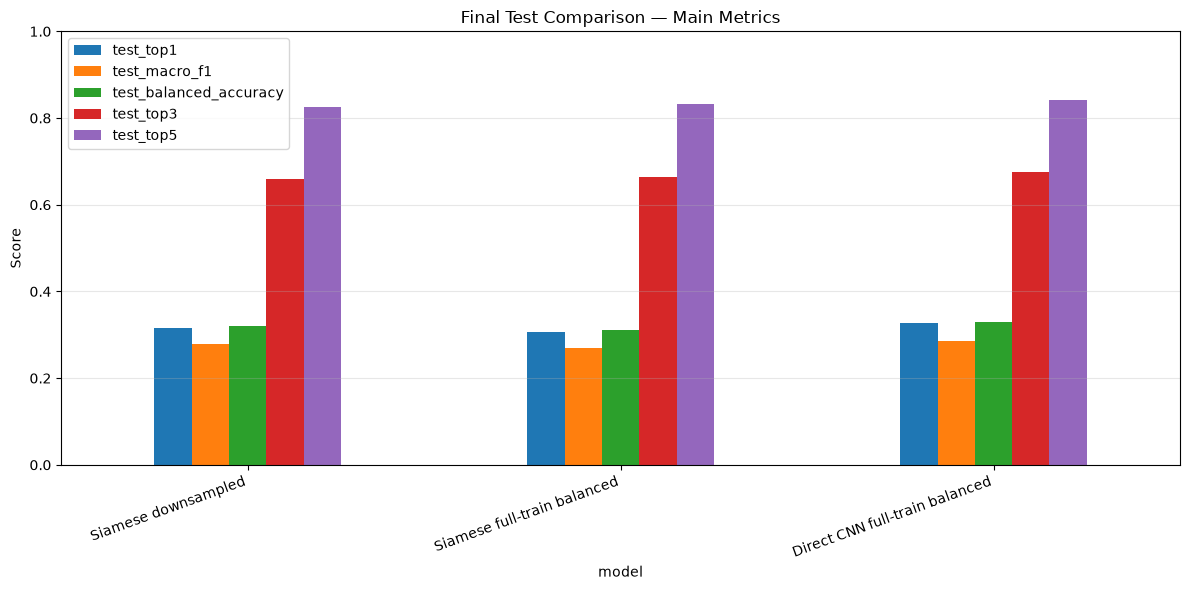

In [13]:
# ============================================================
# CELL 4 — BAR PLOT: MAIN METRICS
# ============================================================

plot_df = metrics_df.set_index("model")[[
    "test_top1",
    "test_macro_f1",
    "test_balanced_accuracy",
    "test_top3",
    "test_top5"
]]

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Final Test Comparison — Main Metrics")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    COMPARISON_DIR / "final_test_main_metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


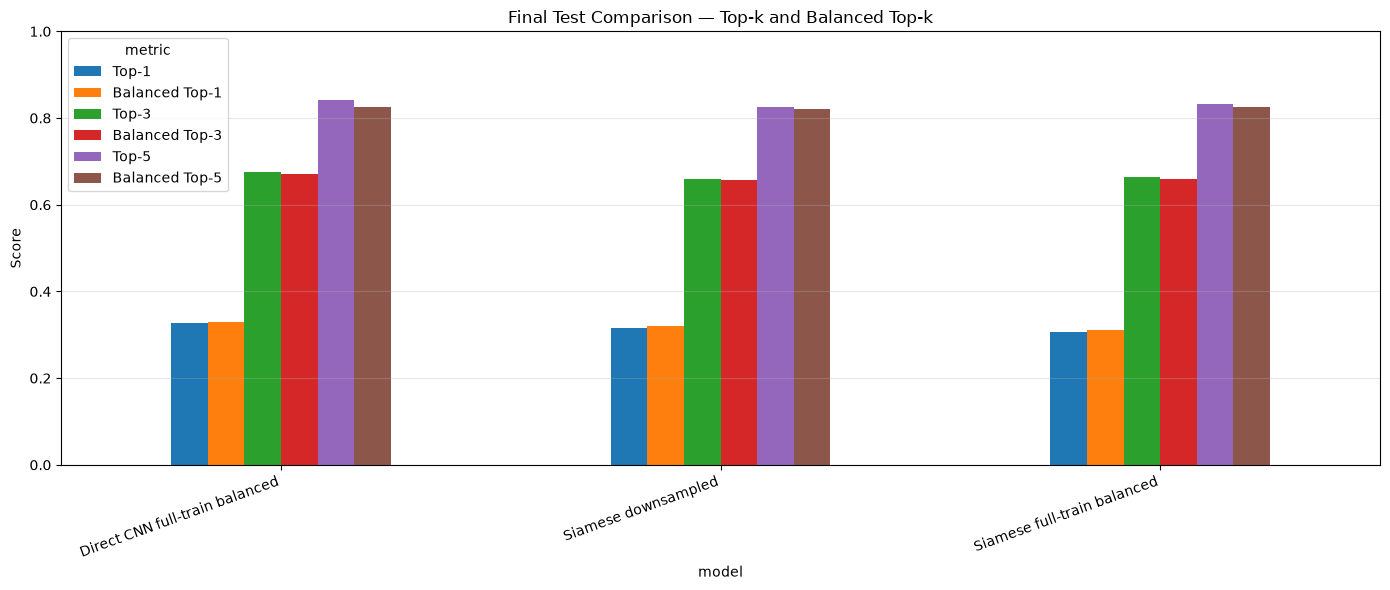

In [14]:
# ============================================================
# CELL 5 — BAR PLOT: TOP-K STANDARD VS BALANCED
# ============================================================

records = []

for _, row in metrics_df.iterrows():
    records.extend([
        {"model": row["model"], "metric": "Top-1", "score": row["test_top1"], "type": "standard"},
        {"model": row["model"], "metric": "Balanced Top-1", "score": row["test_balanced_accuracy"], "type": "balanced"},
        {"model": row["model"], "metric": "Top-3", "score": row["test_top3"], "type": "standard"},
        {"model": row["model"], "metric": "Balanced Top-3", "score": row["test_balanced_top3"], "type": "balanced"},
        {"model": row["model"], "metric": "Top-5", "score": row["test_top5"], "type": "standard"},
        {"model": row["model"], "metric": "Balanced Top-5", "score": row["test_balanced_top5"], "type": "balanced"},
    ])

topk_long = pd.DataFrame(records)

topk_pivot = topk_long.pivot(
    index="model",
    columns="metric",
    values="score"
)[[
    "Top-1",
    "Balanced Top-1",
    "Top-3",
    "Balanced Top-3",
    "Top-5",
    "Balanced Top-5"
]]

ax = topk_pivot.plot(
    kind="bar",
    figsize=(14, 6)
)

ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Final Test Comparison — Top-k and Balanced Top-k")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.savefig(
    COMPARISON_DIR / "final_test_topk_balanced_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [15]:
# ============================================================
# CELL 6 — PER-CLASS RECALL@K TABLES
# ============================================================

full_siamese_per_class_path = (
    SIAMESE_FULL_DIR
    / "fulltrain_balanced_test_per_class_topk.csv"
)

cnn_per_class_path = (
    CNN_DIR
    / "direct_cnn_test_per_class_topk.csv"
)

available = {
    "Siamese full-train balanced": full_siamese_per_class_path.exists(),
    "Direct CNN full-train balanced": cnn_per_class_path.exists(),
}

print("Per-class files available:")
for name, ok in available.items():
    print(f"{name:35s}: {ok}")

per_class_tables = {}

if full_siamese_per_class_path.exists():
    per_class_tables["Siamese full-train balanced"] = pd.read_csv(
        full_siamese_per_class_path
    )

if cnn_per_class_path.exists():
    per_class_tables["Direct CNN full-train balanced"] = pd.read_csv(
        cnn_per_class_path
    )

for name, table in per_class_tables.items():
    print()
    print("=" * 100)
    print(name)
    print("=" * 100)
    display(table)


Per-class files available:
Siamese full-train balanced        : True
Direct CNN full-train balanced     : True

Siamese full-train balanced


,class_id,class_name,support,recall_at_1,recall_at_3,recall_at_5
0,0,gastric cancer,1000,0.502000,0.769000,0.879000
1,1,healthy,1000,0.157000,0.637000,0.771000
2,2,ovarian cancer,1000,0.499000,0.688000,0.861000
3,3,prostate cancer,1000,0.080000,0.538000,0.836000
4,4,colorectal cancer,1000,0.324000,0.690000,0.866000
5,5,lymphoma,1000,0.395000,0.701000,0.855000
6,6,cervical adenocarcinoma,1000,0.269000,0.717000,0.863000
7,7,leukemia,1000,0.236000,0.613000,0.760000
8,8,hypopharyngeal SCC,288,0.184028,0.645833,0.802083
9,9,glioblastoma cancer,296,0.145270,0.486486,0.790541



Direct CNN full-train balanced


,class_id,class_name,support,recall_at_1,recall_at_3,recall_at_5
0,0,gastric cancer,1000,0.545000,0.774000,0.891000
1,1,healthy,1000,0.201000,0.616000,0.757000
2,2,ovarian cancer,1000,0.548000,0.704000,0.883000
3,3,prostate cancer,1000,0.073000,0.591000,0.829000
4,4,colorectal cancer,1000,0.341000,0.673000,0.890000
5,5,lymphoma,1000,0.483000,0.709000,0.882000
6,6,cervical adenocarcinoma,1000,0.166000,0.738000,0.887000
7,7,leukemia,1000,0.277000,0.616000,0.748000
8,8,hypopharyngeal SCC,288,0.222222,0.670139,0.777778
9,9,glioblastoma cancer,296,0.172297,0.608108,0.844595


,class_id,class_name,siamese_recall_at_1,siamese_recall_at_3,siamese_recall_at_5,cnn_recall_at_1,cnn_recall_at_3,cnn_recall_at_5,delta_cnn_minus_siamese_top1,delta_cnn_minus_siamese_top3,delta_cnn_minus_siamese_top5
0,0,gastric cancer,0.502000,0.769000,0.879000,0.545000,0.774000,0.891000,0.043000,0.005000,0.012000
1,1,healthy,0.157000,0.637000,0.771000,0.201000,0.616000,0.757000,0.044000,-0.021000,-0.014000
2,2,ovarian cancer,0.499000,0.688000,0.861000,0.548000,0.704000,0.883000,0.049000,0.016000,0.022000
3,3,prostate cancer,0.080000,0.538000,0.836000,0.073000,0.591000,0.829000,-0.007000,0.053000,-0.007000
4,4,colorectal cancer,0.324000,0.690000,0.866000,0.341000,0.673000,0.890000,0.017000,-0.017000,0.024000
5,5,lymphoma,0.395000,0.701000,0.855000,0.483000,0.709000,0.882000,0.088000,0.008000,0.027000
6,6,cervical adenocarcinoma,0.269000,0.717000,0.863000,0.166000,0.738000,0.887000,-0.103000,0.021000,0.024000
7,7,leukemia,0.236000,0.613000,0.760000,0.277000,0.616000,0.748000,0.041000,0.003000,-0.012000
8,8,hypopharyngeal SCC,0.184028,0.645833,0.802083,0.222222,0.670139,0.777778,0.038194,0.024306,-0.024306
9,9,glioblastoma cancer,0.145270,0.486486,0.790541,0.172297,0.608108,0.844595,0.027027,0.121622,0.054054


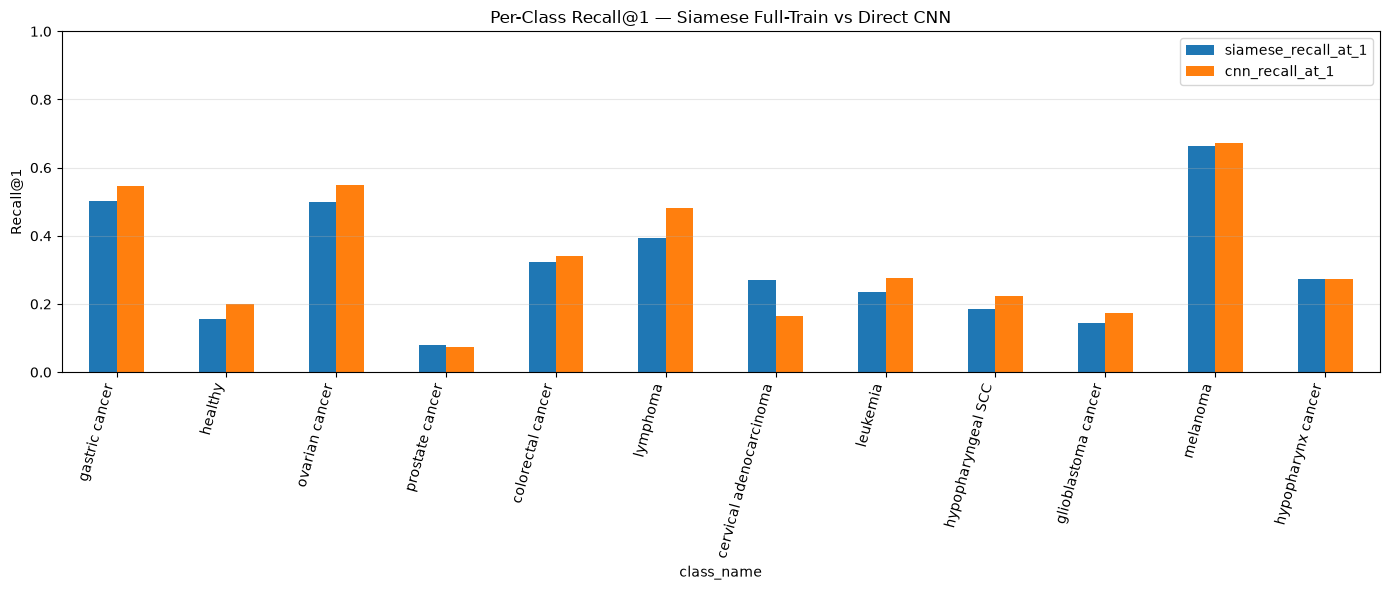

In [16]:
# ============================================================
# CELL 7 — PER-CLASS RECALL@1 COMPARISON
# ============================================================

if {
    "Siamese full-train balanced",
    "Direct CNN full-train balanced"
}.issubset(per_class_tables.keys()):

    siamese_pc = per_class_tables[
        "Siamese full-train balanced"
    ][[
        "class_id",
        "class_name",
        "recall_at_1",
        "recall_at_3",
        "recall_at_5"
    ]].rename(columns={
        "recall_at_1": "siamese_recall_at_1",
        "recall_at_3": "siamese_recall_at_3",
        "recall_at_5": "siamese_recall_at_5",
    })

    cnn_pc = per_class_tables[
        "Direct CNN full-train balanced"
    ][[
        "class_id",
        "recall_at_1",
        "recall_at_3",
        "recall_at_5"
    ]].rename(columns={
        "recall_at_1": "cnn_recall_at_1",
        "recall_at_3": "cnn_recall_at_3",
        "recall_at_5": "cnn_recall_at_5",
    })

    per_class_comparison = siamese_pc.merge(
        cnn_pc,
        on="class_id"
    )

    per_class_comparison["delta_cnn_minus_siamese_top1"] = (
        per_class_comparison["cnn_recall_at_1"]
        - per_class_comparison["siamese_recall_at_1"]
    )

    per_class_comparison["delta_cnn_minus_siamese_top3"] = (
        per_class_comparison["cnn_recall_at_3"]
        - per_class_comparison["siamese_recall_at_3"]
    )

    per_class_comparison["delta_cnn_minus_siamese_top5"] = (
        per_class_comparison["cnn_recall_at_5"]
        - per_class_comparison["siamese_recall_at_5"]
    )

    display(per_class_comparison)

    per_class_comparison.to_csv(
        COMPARISON_DIR / "per_class_siamese_full_vs_direct_cnn.csv",
        index=False
    )

    plot_df = per_class_comparison.set_index("class_name")[[
        "siamese_recall_at_1",
        "cnn_recall_at_1"
    ]]

    ax = plot_df.plot(
        kind="bar",
        figsize=(14, 6)
    )

    ax.set_ylabel("Recall@1")
    ax.set_ylim(0, 1)
    ax.set_title("Per-Class Recall@1 — Siamese Full-Train vs Direct CNN")
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()

    plt.savefig(
        COMPARISON_DIR / "per_class_recall_at_1_siamese_vs_cnn.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:
    print("Per-class comparison skipped: missing per-class files.")


In [17]:
# ============================================================
# CELL 8 — TOP CONFUSIONS: SIAMESE FULL VS DIRECT CNN
# ============================================================

full_siamese_confusions_path = (
    SIAMESE_FULL_DIR
    / "fulltrain_balanced_test_confusions.csv"
)

cnn_confusions_path = (
    CNN_DIR
    / "direct_cnn_test_confusions.csv"
)

print("Confusion files:")
print("Siamese full-train:", full_siamese_confusions_path.exists())
print("Direct CNN:", cnn_confusions_path.exists())

if full_siamese_confusions_path.exists():
    siamese_confusions_df = pd.read_csv(full_siamese_confusions_path)
    print("\nSIAMESE FULL-TRAIN — TOP 20 CONFUSIONS")
    display(siamese_confusions_df.head(20))
else:
    siamese_confusions_df = None

if cnn_confusions_path.exists():
    cnn_confusions_df = pd.read_csv(cnn_confusions_path)
    print("\nDIRECT CNN — TOP 20 CONFUSIONS")
    display(cnn_confusions_df.head(20))
else:
    cnn_confusions_df = None


Confusion files:
Siamese full-train: True
Direct CNN: True

SIAMESE FULL-TRAIN — TOP 20 CONFUSIONS


,true_class_id,true_class,predicted_class_id,predicted_class,count,percentage_of_true_class
0,3,prostate cancer,2,ovarian cancer,308,0.308000
1,8,hypopharyngeal SCC,11,hypopharynx cancer,86,0.298611
2,9,glioblastoma cancer,7,leukemia,65,0.219595
3,1,healthy,10,melanoma,219,0.219000
4,11,hypopharynx cancer,8,hypopharyngeal SCC,24,0.210526
5,6,cervical adenocarcinoma,0,gastric cancer,210,0.210000
6,6,cervical adenocarcinoma,5,lymphoma,203,0.203000
7,4,colorectal cancer,6,cervical adenocarcinoma,190,0.190000
8,6,cervical adenocarcinoma,4,colorectal cancer,169,0.169000
9,7,leukemia,10,melanoma,160,0.160000



DIRECT CNN — TOP 20 CONFUSIONS


,true_class_id,true_class,predicted_class_id,predicted_class,count,percentage_of_true_class
0,3,prostate cancer,2,ovarian cancer,338,0.338000
1,6,cervical adenocarcinoma,0,gastric cancer,261,0.261000
2,6,cervical adenocarcinoma,5,lymphoma,253,0.253000
3,8,hypopharyngeal SCC,11,hypopharynx cancer,65,0.225694
4,1,healthy,10,melanoma,209,0.209000
5,11,hypopharynx cancer,8,hypopharyngeal SCC,22,0.192982
6,9,glioblastoma cancer,7,leukemia,56,0.189189
7,9,glioblastoma cancer,0,gastric cancer,54,0.182432
8,6,cervical adenocarcinoma,4,colorectal cancer,174,0.174000
9,3,prostate cancer,5,lymphoma,165,0.165000


In [18]:
# ============================================================
# CELL 9 — SHARED / MODEL-SPECIFIC CONFUSIONS
# ============================================================

if siamese_confusions_df is not None and cnn_confusions_df is not None:

    key_cols = [
        "true_class",
        "predicted_class"
    ]

    siamese_top = siamese_confusions_df.head(30).copy()
    cnn_top = cnn_confusions_df.head(30).copy()

    shared_confusions = siamese_top.merge(
        cnn_top,
        on=key_cols,
        suffixes=("_siamese", "_cnn")
    )

    shared_confusions["delta_cnn_minus_siamese_pct"] = (
        shared_confusions["percentage_of_true_class_cnn"]
        - shared_confusions["percentage_of_true_class_siamese"]
    )

    print("SHARED TOP CONFUSIONS")
    display(shared_confusions[[
        "true_class",
        "predicted_class",
        "percentage_of_true_class_siamese",
        "percentage_of_true_class_cnn",
        "delta_cnn_minus_siamese_pct"
    ]])

    shared_confusions.to_csv(
        COMPARISON_DIR / "shared_top_confusions_siamese_full_vs_cnn.csv",
        index=False
    )

else:
    print("Shared confusion analysis skipped: missing files.")


SHARED TOP CONFUSIONS


,true_class,predicted_class,percentage_of_true_class_siamese,percentage_of_true_class_cnn,delta_cnn_minus_siamese_pct
0,prostate cancer,ovarian cancer,0.308000,0.338000,0.030000
1,hypopharyngeal SCC,hypopharynx cancer,0.298611,0.225694,-0.072917
2,glioblastoma cancer,leukemia,0.219595,0.189189,-0.030405
3,healthy,melanoma,0.219000,0.209000,-0.010000
4,hypopharynx cancer,hypopharyngeal SCC,0.210526,0.192982,-0.017544
5,cervical adenocarcinoma,gastric cancer,0.210000,0.261000,0.051000
6,cervical adenocarcinoma,lymphoma,0.203000,0.253000,0.050000
7,colorectal cancer,cervical adenocarcinoma,0.190000,0.104000,-0.086000
8,cervical adenocarcinoma,colorectal cancer,0.169000,0.174000,0.005000
9,leukemia,melanoma,0.160000,0.149000,-0.011000


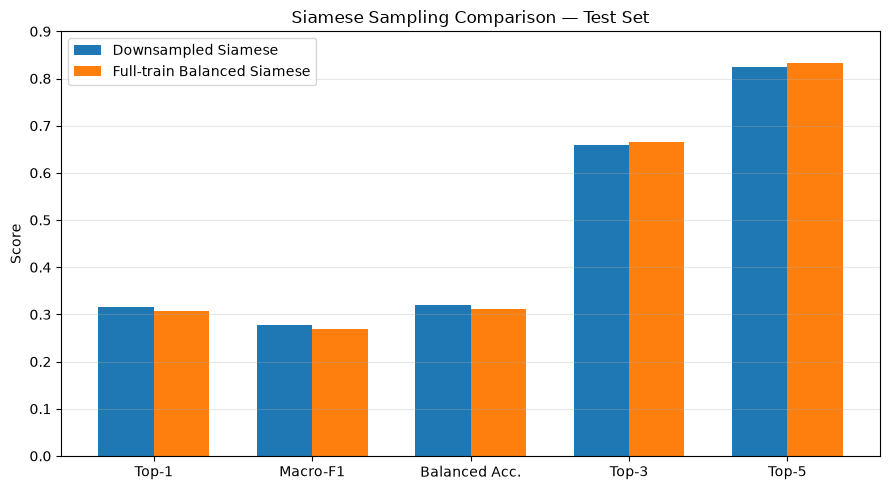

Saved:
D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\final_model_comparison\siamese_sampling_comparison.png


In [2]:
# ============================================================
# SIAMESE SAMPLING COMPARISON — TEST
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

comparison_df = pd.DataFrame({
    "metric": [
        "Top-1",
        "Macro-F1",
        "Balanced Acc.",
        "Top-3",
        "Top-5"
    ],
    "Downsampled Siamese": [
        0.3158,
        0.2784,
        0.3197,
        0.6583,
        0.8253
    ],
    "Full-train Balanced Siamese": [
        0.306847,
        0.268841,
        0.310454,
        0.664799,
        0.833352
    ]
})

x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    x - width / 2,
    comparison_df["Downsampled Siamese"],
    width,
    label="Downsampled Siamese"
)

ax.bar(
    x + width / 2,
    comparison_df["Full-train Balanced Siamese"],
    width,
    label="Full-train Balanced Siamese"
)

ax.set_xticks(x)
ax.set_xticklabels(
    comparison_df["metric"]
)

ax.set_ylabel("Score")
ax.set_ylim(0, 0.9)

ax.set_title(
    "Siamese Sampling Comparison — Test Set"
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.legend()

plt.tight_layout()

OUTPUT_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "final_model_comparison"
    / "siamese_sampling_comparison.png"
)

OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH)

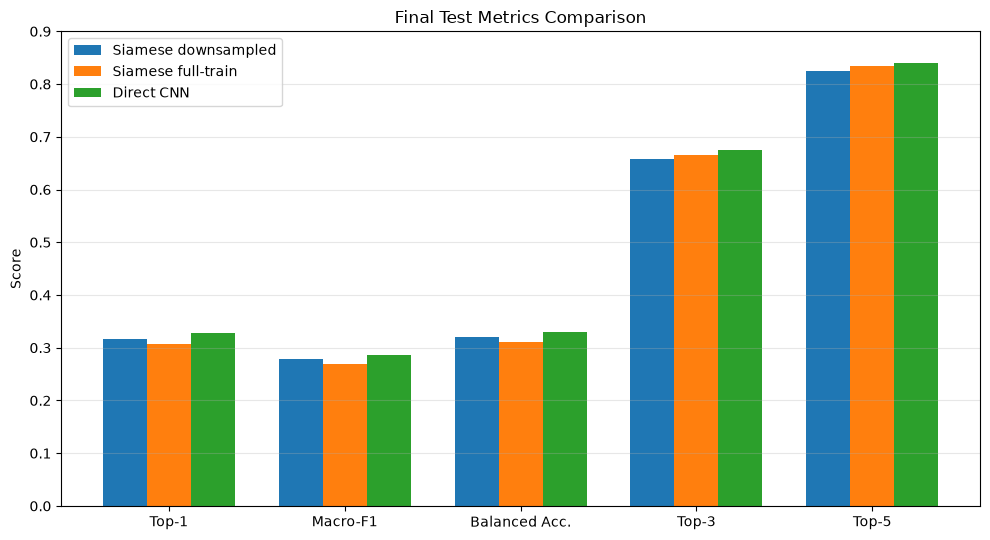

Saved:
D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\final_model_comparison\final_test_metrics_comparison.png


In [3]:
# ============================================================
# FINAL TEST METRICS COMPARISON
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

final_test_df = pd.DataFrame({
    "metric": [
        "Top-1",
        "Macro-F1",
        "Balanced Acc.",
        "Top-3",
        "Top-5"
    ],
    "Siamese downsampled": [
        0.3158,
        0.2784,
        0.3197,
        0.6583,
        0.8253
    ],
    "Siamese full-train": [
        0.306847,
        0.268841,
        0.310454,
        0.664799,
        0.833352
    ],
    "Direct CNN": [
        0.328253,
        0.285780,
        0.330599,
        0.675894,
        0.840861
    ]
})

x = np.arange(len(final_test_df))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.bar(
    x - width,
    final_test_df["Siamese downsampled"],
    width,
    label="Siamese downsampled"
)

ax.bar(
    x,
    final_test_df["Siamese full-train"],
    width,
    label="Siamese full-train"
)

ax.bar(
    x + width,
    final_test_df["Direct CNN"],
    width,
    label="Direct CNN"
)

ax.set_xticks(x)
ax.set_xticklabels(final_test_df["metric"])
ax.set_ylabel("Score")
ax.set_ylim(0, 0.9)
ax.set_title("Final Test Metrics Comparison")
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()

OUTPUT_PATH = (
    PROJECT_ROOT
    / "artifacts"
    / "final_model_comparison"
    / "final_test_metrics_comparison.png"
)

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH)

,Class,Siamese downsampled,Siamese full-train,Direct CNN
0,Gastric cancer,0.5140,0.502000,0.545000
1,Healthy,0.1640,0.157000,0.201000
2,Ovarian cancer,0.4940,0.499000,0.548000
3,Prostate cancer,0.0970,0.080000,0.073000
4,Colorectal cancer,0.3380,0.324000,0.341000
5,Lymphoma,0.4270,0.395000,0.483000
6,Cervical adenocarcinoma,0.2640,0.269000,0.165000
7,Leukemia,0.2330,0.236000,0.277000
8,Hypopharyngeal SCC,0.2014,0.184028,0.222222
9,Glioblastoma cancer,0.1655,0.145270,0.168900


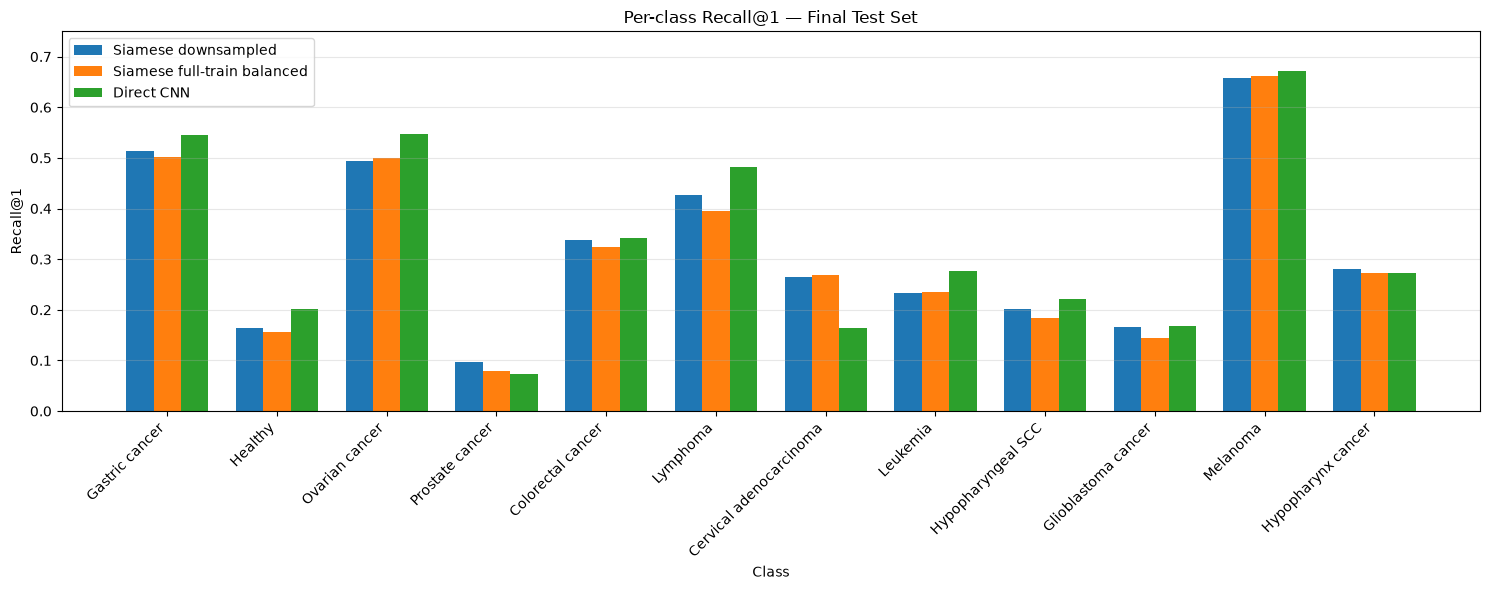

Saved:
D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\final_model_comparison\per_class_recall1_comparison.png


In [4]:
# ============================================================
# PER-CLASS RECALL@1 COMPARISON — FINAL TEST
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Final test results already obtained from notebooks:
# 07b = Siamese downsampled
# 14  = Siamese full-train balanced
# 15  = Direct CNN
# ------------------------------------------------------------

class_names = [
    "Gastric cancer",
    "Healthy",
    "Ovarian cancer",
    "Prostate cancer",
    "Colorectal cancer",
    "Lymphoma",
    "Cervical adenocarcinoma",
    "Leukemia",
    "Hypopharyngeal SCC",
    "Glioblastoma cancer",
    "Melanoma",
    "Hypopharynx cancer"
]

recall_downsampled = [
    0.5140,
    0.1640,
    0.4940,
    0.0970,
    0.3380,
    0.4270,
    0.2640,
    0.2330,
    0.2014,
    0.1655,
    0.6578,
    0.2807
]

recall_fulltrain = [
    0.5020,
    0.1570,
    0.4990,
    0.0800,
    0.3240,
    0.3950,
    0.2690,
    0.2360,
    0.184028,
    0.145270,
    0.662222,
    0.271930
]

recall_cnn = [
    0.5450,
    0.2010,
    0.5480,
    0.0730,
    0.3410,
    0.4830,
    0.1650,
    0.2770,
    0.222222,
    0.1689,
    0.671111,
    0.271930
]

comparison_df = pd.DataFrame({
    "Class": class_names,
    "Siamese downsampled": recall_downsampled,
    "Siamese full-train": recall_fulltrain,
    "Direct CNN": recall_cnn
})

display(comparison_df)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(
    x - width,
    recall_downsampled,
    width,
    label="Siamese downsampled"
)

ax.bar(
    x,
    recall_fulltrain,
    width,
    label="Siamese full-train balanced"
)

ax.bar(
    x + width,
    recall_cnn,
    width,
    label="Direct CNN"
)

ax.set_ylabel("Recall@1")
ax.set_xlabel("Class")
ax.set_title("Per-class Recall@1 — Final Test Set")

ax.set_xticks(x)
ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_ylim(0, 0.75)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "../artifacts/final_model_comparison"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "per_class_recall1_comparison.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH.resolve())

,Confusion,Siamese full-train,Direct CNN
0,Prostate → Ovarian,30.80,33.80
1,Hypopharyngeal SCC → Hypopharynx,29.86,22.57
2,Glioblastoma → Leukemia,21.96,18.92
3,Healthy → Melanoma,21.90,20.90
4,Hypopharynx → Hypopharyngeal SCC,21.05,19.30
5,Cervical → Gastric,21.00,26.10
6,Cervical → Lymphoma,20.30,25.30
7,Colorectal → Cervical,19.00,10.40
8,Leukemia → Glioblastoma,14.40,9.00
9,Prostate → Lymphoma,12.50,16.50


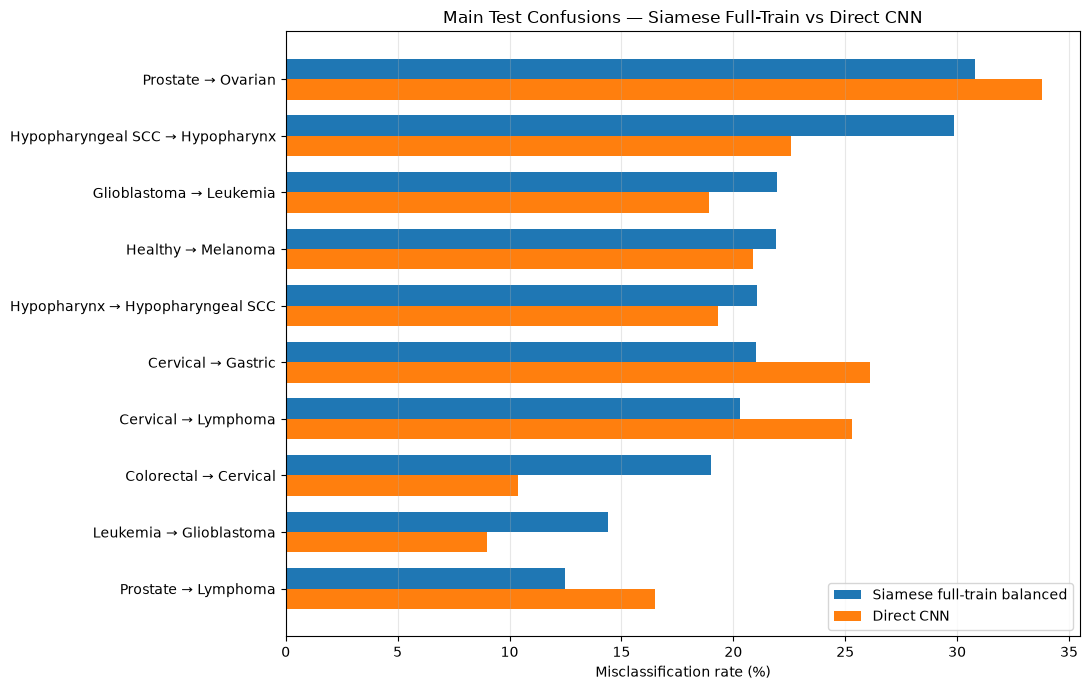

Saved:
D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\final_model_comparison\main_confusions_comparison.png


In [5]:
# ============================================================
# MAIN CONFUSIONS COMPARISON
# Siamese full-train vs Direct CNN
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

confusions = [
    "Prostate → Ovarian",
    "Hypopharyngeal SCC → Hypopharynx",
    "Glioblastoma → Leukemia",
    "Healthy → Melanoma",
    "Hypopharynx → Hypopharyngeal SCC",
    "Cervical → Gastric",
    "Cervical → Lymphoma",
    "Colorectal → Cervical",
    "Leukemia → Glioblastoma",
    "Prostate → Lymphoma",
]

siamese_fulltrain = [
    30.80,
    29.86,
    21.96,
    21.90,
    21.05,
    21.00,
    20.30,
    19.00,
    14.40,
    12.50,
]

direct_cnn = [
    33.80,
    22.57,
    18.92,
    20.90,
    19.30,
    26.10,
    25.30,
    10.40,
    9.00,
    16.50,
]

comparison_df = pd.DataFrame({
    "Confusion": confusions,
    "Siamese full-train": siamese_fulltrain,
    "Direct CNN": direct_cnn
})

display(comparison_df)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

y = np.arange(len(confusions))
height = 0.36

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    y - height / 2,
    siamese_fulltrain,
    height,
    label="Siamese full-train balanced"
)

ax.barh(
    y + height / 2,
    direct_cnn,
    height,
    label="Direct CNN"
)

ax.set_yticks(y)
ax.set_yticklabels(confusions)

ax.invert_yaxis()

ax.set_xlabel("Misclassification rate (%)")
ax.set_title(
    "Main Test Confusions — Siamese Full-Train vs Direct CNN"
)

ax.grid(axis="x", alpha=0.3)
ax.legend()

plt.tight_layout()

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

OUTPUT_DIR = Path(
    "../artifacts/final_model_comparison"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

OUTPUT_PATH = (
    OUTPUT_DIR
    / "main_confusions_comparison.png"
)

plt.savefig(
    OUTPUT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(OUTPUT_PATH.resolve())